In [1]:
# LAB 3
# News Categorization using TF-IDF and Naive Bayes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import time
import joblib

from wordcloud import WordCloud

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.metrics.pairwise import cosine_similarity

In [4]:
# Load Dataset

df = pd.read_csv("bbc_news_dataset.csv")

print(df.head())
print(df.info())

   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business
<class 'pandas.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ArticleId  1490 non-null   int64
 1   Text       1490 non-null   str  
 2   Category   1490 non-null   str  
dtypes: int64(1), str(2)
memory usage: 35.1 KB
None


In [5]:
# Separate Features and Labels

X = df["Text"]
y = df["Category"]

In [6]:
# Explore Dataset

print("\nCategories")
print(df["Category"].unique())

print("\nCount")
print(df["Category"].value_counts())



Categories
<StringArray>
['business', 'tech', 'politics', 'sport', 'entertainment']
Length: 5, dtype: str

Count
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


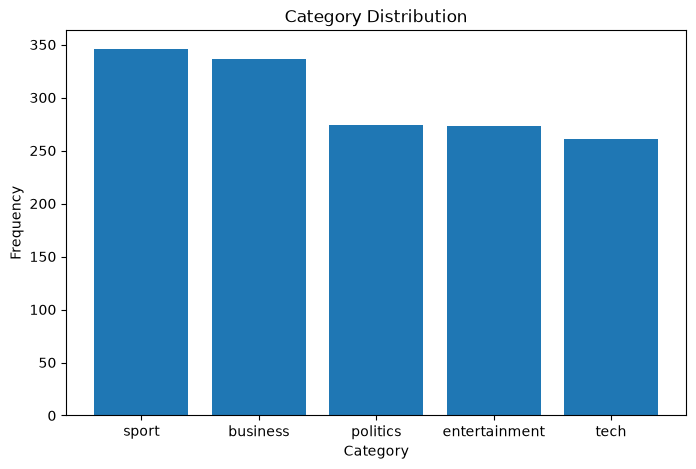

In [7]:
# Category Distribution

plt.figure(figsize=(8,5))

plt.bar(
    df["Category"].value_counts().index,
    df["Category"].value_counts().values
)

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Frequency")

plt.show()

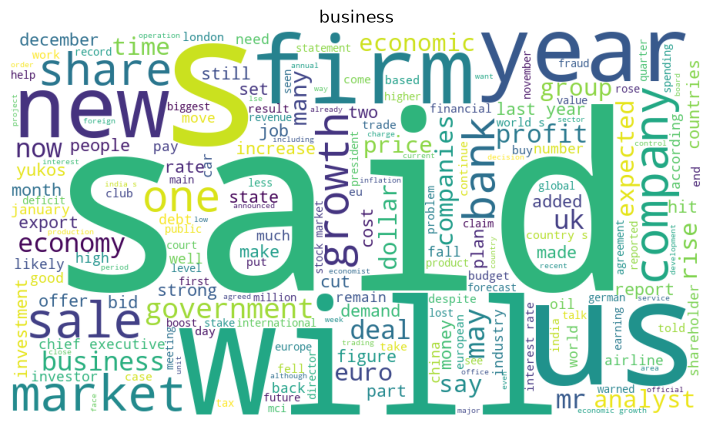

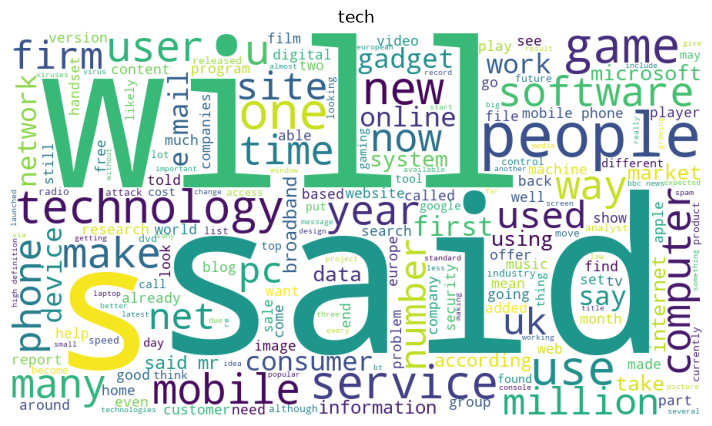

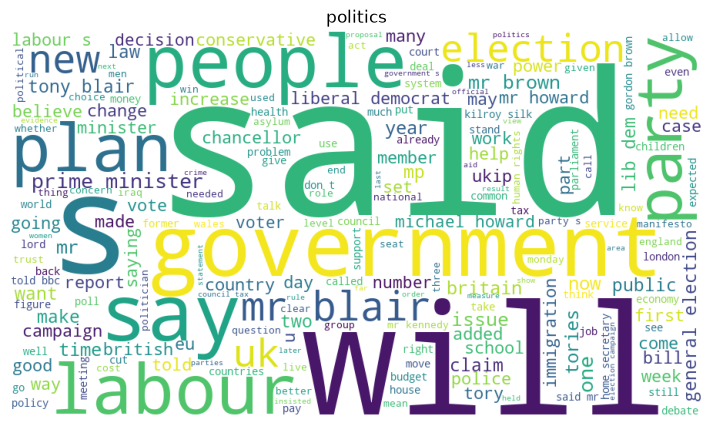

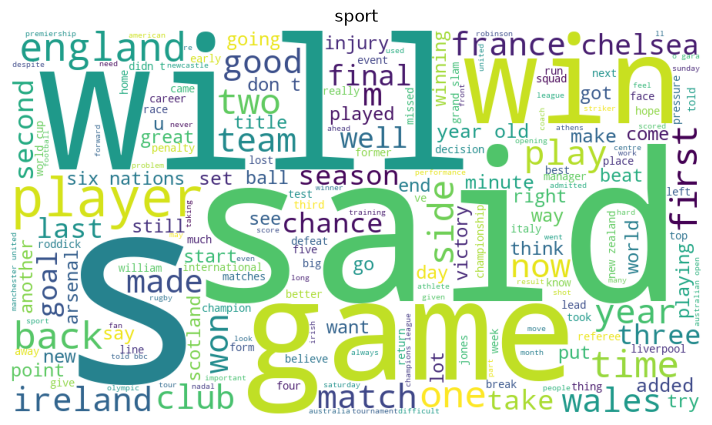

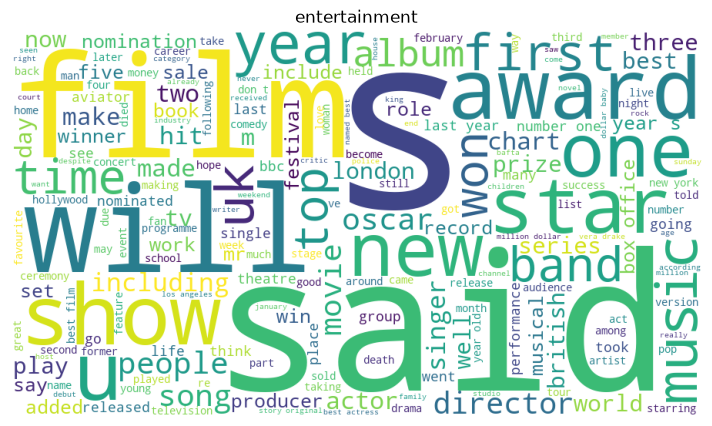

In [8]:
# Word Clouds

categories = df["Category"].unique()

for cat in categories:
    text = " ".join(df[df["Category"]==cat]["Text"])
    wc = WordCloud(
        width=900,
        height=500,
        background_color="white"
    ).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(cat)
    plt.show()

In [9]:
# Train Test Split (80-20)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [10]:
# TF-IDF + Naive Bayes Model

model = Pipeline([("tfidf",TfidfVectorizer(stop_words="english")),("classifier",MultinomialNB())])

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [11]:
# Evaluation

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred,average="weighted")

recall = recall_score(y_test,y_pred,average="weighted")

f1 = f1_score(y_test,y_pred,average="weighted")

print("\nAccuracy :",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

print("\nClassification Report\n")

print(classification_report(y_test,y_pred))


Accuracy : 0.9731543624161074
Precision: 0.9735085862444682
Recall: 0.9731543624161074
F1 Score: 0.9731145702128726

Classification Report

               precision    recall  f1-score   support

     business       0.96      0.99      0.97        67
entertainment       1.00      0.96      0.98        55
     politics       0.98      0.95      0.96        55
        sport       0.97      1.00      0.99        69
         tech       0.96      0.96      0.96        52

     accuracy                           0.97       298
    macro avg       0.97      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



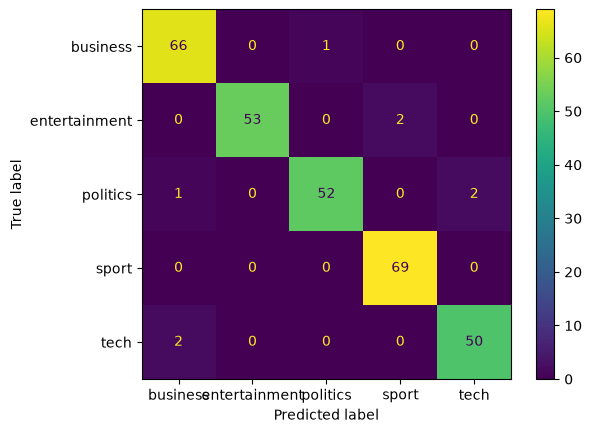

In [12]:
# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_).plot()
plt.show()

In [13]:
# TASK 2
# Experiment TF-IDF Parameters

settings=[
    {"max_features":1000,"ngram_range":(1,1),"min_df":2},
    {"max_features":3000,"ngram_range":(1,2),"min_df":2},
    {"max_features":5000,"ngram_range":(1,3),"min_df":1}
]

print("\nTF-IDF Experiments")

for s in settings:
    pipe=Pipeline([("tfidf",TfidfVectorizer(
        stop_words="english",
        max_features=s["max_features"],
        ngram_range=s["ngram_range"],
        min_df=s["min_df"])),("clf",MultinomialNB())])

    pipe.fit(X_train,y_train)
    pred=pipe.predict(X_test)
    acc=accuracy_score(y_test,pred)
    print(s,"Accuracy =",acc)


TF-IDF Experiments
{'max_features': 1000, 'ngram_range': (1, 1), 'min_df': 2} Accuracy = 0.9630872483221476
{'max_features': 3000, 'ngram_range': (1, 2), 'min_df': 2} Accuracy = 0.9630872483221476
{'max_features': 5000, 'ngram_range': (1, 3), 'min_df': 1} Accuracy = 0.9765100671140939


In [14]:
# TASK 3
# Five Custom Articles

articles=[
"Apple announced its newest AI powered smartphone with improved processors.",
"The government announced new tax reforms and parliament approved the bill.",
"The football team won the championship after an exciting final match.",
"A famous actor received the best performance award during the film festival.",
"The stock market increased because of strong company earnings."
]

prediction=model.predict(articles)

print("\nCustom Predictions")

for article,label in zip(articles,prediction):
    print("="*60)
    print(article)
    print("Prediction:",label)


Custom Predictions
Apple announced its newest AI powered smartphone with improved processors.
Prediction: tech
The government announced new tax reforms and parliament approved the bill.
Prediction: politics
The football team won the championship after an exciting final match.
Prediction: sport
A famous actor received the best performance award during the film festival.
Prediction: entertainment
The stock market increased because of strong company earnings.
Prediction: business


In [15]:
# TASK 4
# Save Model
joblib.dump(model,"news_model.joblib")

print("\nModel Saved")
loaded_model=joblib.load("news_model.joblib")
sample=["Google launches new AI model."]

print(loaded_model.predict(sample))


Model Saved
['tech']


In [16]:
# TASK 5
# Different Train Test Split

splits=[0.30,0.20,0.10]

for test in splits:
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=test,random_state=42,stratify=y)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    acc=accuracy_score(y_test,pred)

    print(f"Train:{int((1-test)*100)} Test:{int(test*100)} Accuracy:{acc}")

Train:70 Test:30 Accuracy:0.9642058165548099
Train:80 Test:20 Accuracy:0.9731543624161074
Train:90 Test:10 Accuracy:0.9865771812080537


In [17]:
# TASK 7
# Five Fold Cross Validation

scores=cross_val_score(model,X,y,cv=5,scoring="accuracy")

print("\nCross Validation Scores")
print(scores)
print("Mean Accuracy:",scores.mean())
print("Std:",scores.std())


Cross Validation Scores
[0.96308725 0.95302013 0.96979866 0.97986577 0.96644295]
Mean Accuracy: 0.9664429530201343
Std: 0.00875060725530559


In [18]:
# TASK 9
# Compare Algorithms

models={
    "Naive Bayes":MultinomialNB(),
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "SVM":LinearSVC()
}

results=[]

print("\nAlgorithm Comparison")

for name,clf in models.items():
    pipeline=Pipeline([("tfidf",TfidfVectorizer(stop_words="english")),("clf",clf)])

    start=time.time()
    pipeline.fit(X_train,y_train)
    train_time=time.time()-start
    start=time.time()
    pred=pipeline.predict(X_test)
    pred_time=time.time()-start
    acc=accuracy_score(y_test,pred)
    results.append([name,acc,train_time,pred_time])

comparison=pd.DataFrame(results,columns=["Algorithm","Accuracy","Training Time","Prediction Time"])

print(comparison)


Algorithm Comparison
             Algorithm  Accuracy  Training Time  Prediction Time
0          Naive Bayes  0.986577       0.533398         0.046673
1  Logistic Regression  0.993289       1.167299         0.046764
2                  SVM  0.979866       0.688446         0.057215


In [19]:
# TASK 10
# Recommendation System

print("\nRecommendation System")

tfidf=TfidfVectorizer(stop_words="english")
matrix=tfidf.fit_transform(df["Text"])
query="Apple introduces new AI chip"
query_vector=tfidf.transform([query])
pred=model.predict([query])[0]
indices=df[df["Category"]==pred].index
similarity=cosine_similarity(query_vector,matrix[indices])
top=similarity.argsort()[0][-3:][::-1]
print("Predicted Category:",pred)
print("\nTop 3 Similar Articles")

for i in top:
    print("="*80)
    print(df.iloc[indices[i]]["Text"][:400])
print("\nFinished Successfully")


Recommendation System
Predicted Category: tech

Top 3 Similar Articles
first look at playstation 3 chip some details of the chip inside sony s playstation 3 have been revealed.  sony  ibm and toshiba have released limited data about the so-called cell chip that will be able to carry out trillions of calculations per second. the chip will be made of several different processing cores that work on tasks together. the playstation 3 is expected in 2006 but developers are
apple makes blogs reveal sources apple has won its legal fight to make three bloggers reveal who told them about unreleased products.  the bid to unmask the employees leaking information was launched in december 2004 following online articles about apple s asteroid product. now apple has won the right to see e-mail records from the three bloggers to root out the culprit. a lawyer for the three blo
apple sues  tiger  file sharers apple has taken more legal action to stop online leaks of its new products.  the computer gian